# Exploratory Data Analysis and Cleaning

This notebook demonstrates data-quality assessment, string normalization, missing-value analysis, feature extraction, imputation, and descriptive visualization across three datasets.

## Cleaning a small DataFrame

The first example uses synthetic flight data adapted from [100 pandas puzzles](https://github.com/ajcr/100-pandas-puzzles/blob/master/100-pandas-puzzles-with-solutions.ipynb).

In [ ]:
import numpy as np
import pandas as pd

df = pd.DataFrame({'From_To': ['LoNDon_paris', 'MAdrid_miLAN', 'londON_StockhOlm',
                               'Budapest_PaRis', 'Brussels_londOn'],
              'FlightNumber': [10045, np.nan, 10065, np.nan, 10085],
              'RecentDelays': [[23, 47], [], [24, 43, 87], [13], [67, 32]],
                   'Airline': ['KLM(!)', '<Air France> (12)', '(British Airways. )',
                               '12. Air France', '"Swiss Air"']})
df

,From_To,FlightNumber,RecentDelays,Airline
0,LoNDon_paris,10045.0,"[23, 47]",KLM(!)
1,MAdrid_miLAN,NaN,[],<Air France> (12)
2,londON_StockhOlm,10065.0,"[24, 43, 87]",(British Airways. )
3,Budapest_PaRis,NaN,[13],12. Air France
4,Brussels_londOn,10085.0,"[67, 32]","""Swiss Air"""


Missing flight numbers follow a sequence that increases by 10. Linear interpolation restores the missing values, and the completed column is converted from floating point to integer.

In [ ]:
df['FlightNumber'] = df['FlightNumber'].interpolate().astype(int)
df['FlightNumber']


0    10045
1    10055
2    10065
3    10075
4    10085
Name: FlightNumber, dtype: int64

The combined `From_To` field is split on the underscore delimiter into separate origin and destination columns.

In [ ]:
temp = df.From_To.str.split('_', expand=True)
temp.columns = ['From', 'To']
temp

City names use inconsistent capitalization. Applying `capitalize()` standardizes each value.

In [ ]:
temp['From'] = temp['From'].str.capitalize()
temp['To'] = temp['To'].str.capitalize()
temp

The original combined route field is removed and replaced with the normalized origin and destination columns.

In [ ]:
df = df.drop('From_To', axis=1)
df = df.join(temp)
df

The airline values contain stray punctuation and numeric characters. A regular expression extracts and trims the airline names.

In [ ]:
df['Airline'] = df['Airline'].str.extract('([a-zA-Z\s]+)', expand=False).str.strip()
# Remove leading and trailing whitespace
df.Airline


Each `RecentDelays` value is a list. Expanding these lists produces separate `delay_1`, `delay_2`, and `delay_3` columns, with `NaN` where a flight has fewer recorded delays.

In [ ]:
# Expand each delay list into a separate Series

delays = df['RecentDelays'].apply(pd.Series)
delays.columns = ['delay_{}'.format(n) for n in range(1, len(delays.columns)+1)]
df = df.drop('RecentDelays', axis=1).join(delays)

In [ ]:
print(delays)

The transformed DataFrame now separates routes and delays into analysis-ready columns.

In [ ]:
df

## San Francisco building permits

The second analysis uses the [San Francisco Building Permit Applications dataset](https://www.kaggle.com/datasets/aparnashastry/building-permit-applications-data). The missing-data workflow is adapted from Kaggle's [Data Cleaning Challenge](https://www.kaggle.com/code/rtatman/data-cleaning-challenge-handling-missing-values). The records cover permits issued from January 2013 through February 2018.

In [29]:
# Kaggle credentials are supplied through environment variables or ~/.kaggle/kaggle.json

import os

In [44]:
! kaggle datasets download -d aparnashastry/building-permit-applications-data

 89% 16.0M/18.0M [00:01<00:00, 20.0MB/s]
100% 18.0M/18.0M [00:01<00:00, 12.8MB/s]


The downloaded archive is extracted and loaded into a pandas DataFrame.

In [45]:
! unzip building-permit-applications-data.zip

sfPermits = pd.read_csv("Building_Permits.csv")

Archive:  building-permit-applications-data.zip
  inflating: Building_Permits.csv    
  inflating: DataDictionaryBuildingPermit.xlsx  


<ipython-input-45-a66231d7dc25>:3: DtypeWarning: Columns (22,32) have mixed types. Specify dtype option on import or set low_memory=False.
  sfPermits = pd.read_csv("Building_Permits.csv")


A reproducible random sample provides an initial view of the dataset.

In [46]:
np.random.seed(0)
sfPermits.sample(5)

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
40553,201403039652,8,otc alterations permit,03/03/2014,3732,008,400,NaN,Clementina,St,...,NaN,NaN,1.0,constr type 1,NaN,6.0,South of Market,94103.0,"(37.780460571778164, -122.40450626524974)",1334094491645
169731,201510159735,3,additions alterations or repairs,10/15/2015,2609,028,79,NaN,Buena Vista,Tr,...,5.0,wood frame (5),5.0,wood frame (5),NaN,8.0,Castro/Upper Market,94117.0,"(37.76757916496494, -122.43793170417105)",1399356139170
19180,M409787,8,otc alterations permit,07/22/2013,4624,031,178,NaN,West Point,Rd,...,NaN,NaN,NaN,NaN,NaN,10.0,Bayview Hunters Point,94124.0,"(37.73524725436046, -122.38063828309745)",1311685491725
68047,201411191888,8,otc alterations permit,11/19/2014,0039,109,294,NaN,Francisco,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,North Beach,94133.0,"(37.805257822817126, -122.40998545760392)",1362881288870
64238,M527228,8,otc alterations permit,10/14/2014,1251,002,707,NaN,Cole,St,...,NaN,NaN,NaN,NaN,NaN,5.0,Haight Ashbury,94117.0,"(37.76836885973765, -122.45074431487859)",135886493776


The sample reveals extensive missing data. The following calculation measures the proportion of missing cells across the full dataset.

In [47]:
# Calculate the total number of cells
totalCells = np.product(sfPermits.shape)

# Count missing values in each column
missingCount = sfPermits.isnull().sum()

# Calculate the total number of missing values
totalMissing = missingCount.sum()

# Calculate the percentage of missing cells
print("The SF Permits dataset contains", round(((totalMissing/totalCells) * 100), 2), "%", "missing values.")

The SF Permits dataset contains 26.26 % missing values.


`Street Number Suffix` and `Zipcode` both contain missing values, but their meaning differs: a suffix may not exist for an address, whereas every address should have a ZIP code.

In [48]:
missingCount[['Street Number Suffix', 'Zipcode']]

Street Number Suffix    196684
Zipcode                   1716
dtype: int64

Missing-value percentages help distinguish structurally absent values from incomplete records.

In [49]:
print("Percent missing data in Street Number Suffix column =", (round(((missingCount['Street Number Suffix'] / sfPermits.shape[0]) * 100), 2)))
print("Percent missing data in Zipcode column =", (round(((missingCount['Zipcode'] / sfPermits.shape[0]) * 100), 2)))

Percent missing data in Street Number Suffix column = 98.89
Percent missing data in Zipcode column = 0.86


Nearly all `Street Number Suffix` values are absent because most addresses do not use a suffix. Missing ZIP codes are more likely to represent unrecorded data.

### Effects of dropping incomplete rows

In [50]:
sfPermits.dropna()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID


Dropping every row with at least one missing value removes the entire dataset. This demonstrates why indiscriminate row deletion is unsuitable when sparsely populated fields are common.

### Effects of dropping incomplete columns

In [51]:
sfPermitsCleanCols = sfPermits.dropna(axis=1)
sfPermitsCleanCols.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Current Status,Current Status Date,Filed Date,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,Ellis,expired,12/21/2017,05/06/2015,1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,Geary,issued,08/03/2017,04/19/2016,1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,Pacific,withdrawn,09/26/2017,05/27/2016,1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,Pacific,complete,07/24/2017,11/07/2016,1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,Market,issued,12/01/2017,11/28/2016,144548169992


In [52]:
print("Columns in original dataset: %d \n" % sfPermits.shape[1])
print("Columns with na's dropped: %d" % sfPermitsCleanCols.shape[1])

Columns in original dataset: 43 

Columns with na's dropped: 12


Dropping every column containing a missing value preserves complete records but discards substantial information. As a simple imputation demonstration, missing values are forward-filled and any remaining gaps are replaced with zero. This approach is illustrative rather than appropriate for unrelated permit records.

In [61]:
imputeSfPermits = sfPermits.fillna(method='ffill', axis=0).fillna("0")

imputeSfPermits.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,0,Ellis,St,...,3.0,constr type 3,0,0,0,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,0,Geary,St,...,3.0,constr type 3,0,0,0,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,0,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,0,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,0,Pacific,Av,...,5.0,wood frame (5),5.0,wood frame (5),0,3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,0,Market,St,...,3.0,constr type 3,5.0,wood frame (5),0,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",144548169992


### Extract geographic coordinates

The `Location` field contains latitude and longitude in a single string. The values are parsed into separate numeric columns.

In [79]:
# Parse Location into numeric latitude and longitude columns
temp2 = imputeSfPermits['Location'].str.extract('([0-9.]+, [0-9.-]+)', expand=False).str.strip()
temp2 = temp2.str.split(',', expand=True)
temp2.columns = ['Latitude', 'Longitude']
temp2['Latitude'] = temp2['Latitude'].astype(float)
temp2['Longitude'] = temp2['Longitude'].astype(float)

imputeSfPermits = imputeSfPermits.drop('Location', axis=1)
imputeSfPermits = imputeSfPermits.join(temp2)
imputeSfPermits

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Record ID,Latitude,Longitude
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,0,Ellis,St,...,constr type 3,0,0,0,3.0,Tenderloin,94102.0,1380611233945,37.785719,-122.408523
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,0,Geary,St,...,constr type 3,0,0,0,3.0,Tenderloin,94102.0,1420164406718,37.787340,-122.410632
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,0,Pacific,Av,...,constr type 1,1.0,constr type 1,0,3.0,Russian Hill,94109.0,1424856504716,37.794657,-122.422326
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,0,Pacific,Av,...,wood frame (5),5.0,wood frame (5),0,3.0,Nob Hill,94109.0,1443574295566,37.795959,-122.415574
4,201611283529,6,demolitions,11/28/2016,0342,001,950,0,Market,St,...,constr type 3,5.0,wood frame (5),0,6.0,Tenderloin,94102.0,144548169992,37.783153,-122.409509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198895,M862628,8,otc alterations permit,12/05/2017,0113,017A,1228,A,Montgomery,St,...,wood frame (5),5.0,wood frame (5),Y,4.0,Sunset/Parkside,94116.0,1489337276729,37.749766,-122.488244
198896,201712055595,8,otc alterations permit,12/05/2017,0271,014,580,A,Bush,St,...,wood frame (5),5.0,wood frame (5),Y,4.0,Sunset/Parkside,94116.0,1489462354993,37.749766,-122.488244
198897,M863507,8,otc alterations permit,12/06/2017,4318,019,1568,A,Indiana,St,...,wood frame (5),5.0,wood frame (5),Y,4.0,Sunset/Parkside,94116.0,1489539379952,37.749766,-122.488244
198898,M863747,8,otc alterations permit,12/06/2017,0298,029,795,A,Sutter,St,...,wood frame (5),5.0,wood frame (5),Y,4.0,Sunset/Parkside,94116.0,1489608233656,37.749766,-122.488244


The mean latitude and longitude provide a basic geographic summary of the permit locations.

In [93]:
# Compute mean latitude and longitude
latavg = imputeSfPermits['Latitude'].sum() / len(imputeSfPermits['Latitude'])
longavg = imputeSfPermits['Longitude'].sum() / len(imputeSfPermits['Longitude'])
print(latavg, longavg)

37.76876002962612 -122.43180700094423


## IMDb movie data

The third analysis uses the [IMDb 5000 Movie Dataset](https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset) and demonstrates threshold-based row removal, column-level missingness analysis, type-aware imputation, renaming, and visualization.

In [101]:
! kaggle datasets download -d carolzhangdc/imdb-5000-movie-dataset

imdb-5000-movie-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [102]:
! unzip imdb-5000-movie-dataset.zip

Archive:  imdb-5000-movie-dataset.zip
replace movie_metadata.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

The extracted CSV file is loaded into a DataFrame.

In [121]:
imdb_df = pd.read_csv('movie_metadata.csv')
imdb_df.head(10)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
5,Color,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,...,738.0,English,USA,PG-13,263700000.0,2012.0,632.0,6.6,2.35,24000
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,James Franco,24000.0,336530303.0,Action|Adventure|Romance,...,1902.0,English,USA,PG-13,258000000.0,2007.0,11000.0,6.2,2.35,0
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,Donna Murphy,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,...,387.0,English,USA,PG,260000000.0,2010.0,553.0,7.8,1.85,29000
8,Color,Joss Whedon,635.0,141.0,0.0,19000.0,Robert Downey Jr.,26000.0,458991599.0,Action|Adventure|Sci-Fi,...,1117.0,English,USA,PG-13,250000000.0,2015.0,21000.0,7.5,2.35,118000
9,Color,David Yates,375.0,153.0,282.0,10000.0,Daniel Radcliffe,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,...,973.0,English,UK,PG,250000000.0,2009.0,11000.0,7.5,2.35,10000


Rows with fewer than 20 non-null fields are removed because they contain too little information for meaningful analysis.

In [122]:
numrows_before, _ = imdb_df.shape
imdb_df = imdb_df.dropna(axis=0, thresh=20)
numrows_after, _ = imdb_df.shape
numrows_removed = numrows_before - numrows_after

print('{} rows removed'.format(numrows_removed))

7 rows removed


In [123]:
imdb_df.head(10)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
5,Color,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,...,738.0,English,USA,PG-13,263700000.0,2012.0,632.0,6.6,2.35,24000
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,James Franco,24000.0,336530303.0,Action|Adventure|Romance,...,1902.0,English,USA,PG-13,258000000.0,2007.0,11000.0,6.2,2.35,0
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,Donna Murphy,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,...,387.0,English,USA,PG,260000000.0,2010.0,553.0,7.8,1.85,29000
8,Color,Joss Whedon,635.0,141.0,0.0,19000.0,Robert Downey Jr.,26000.0,458991599.0,Action|Adventure|Sci-Fi,...,1117.0,English,USA,PG-13,250000000.0,2015.0,21000.0,7.5,2.35,118000
9,Color,David Yates,375.0,153.0,282.0,10000.0,Daniel Radcliffe,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,...,973.0,English,UK,PG,250000000.0,2009.0,11000.0,7.5,2.35,10000
10,Color,Zack Snyder,673.0,183.0,0.0,2000.0,Lauren Cohan,15000.0,330249062.0,Action|Adventure|Sci-Fi,...,3018.0,English,USA,PG-13,250000000.0,2016.0,4000.0,6.9,2.35,197000


Removing every row with any missing value would discard too much data. Column-level missing counts identify fields that require targeted handling.

In [124]:
missingCount = imdb_df.isnull().sum()
missingCount

color                         16
director_name                100
num_critic_for_reviews        46
duration                      14
director_facebook_likes      100
actor_3_facebook_likes        18
actor_2_name                   9
actor_1_facebook_likes         6
gross                        877
genres                         0
actor_1_name                   6
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  18
facenumber_in_poster          13
plot_keywords                150
movie_imdb_link                0
num_user_for_reviews          17
language                       9
country                        3
content_rating               296
budget                       487
title_year                   102
actor_2_facebook_likes         9
imdb_score                     0
aspect_ratio                 322
movie_facebook_likes           0
dtype: int64

Missing values in string columns are replaced with empty strings.

In [125]:
imdb_df['color'] = imdb_df['color'].fillna('')
missingCount = imdb_df.isnull().sum()
missingCount

color                          0
director_name                100
num_critic_for_reviews        46
duration                      14
director_facebook_likes      100
actor_3_facebook_likes        18
actor_2_name                   9
actor_1_facebook_likes         6
gross                        877
genres                         0
actor_1_name                   6
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  18
facenumber_in_poster          13
plot_keywords                150
movie_imdb_link                0
num_user_for_reviews          17
language                       9
country                        3
content_rating               296
budget                       487
title_year                   102
actor_2_facebook_likes         9
imdb_score                     0
aspect_ratio                 322
movie_facebook_likes           0
dtype: int64

In [134]:
# Replace missing string values with empty strings

for c, t in imdb_df.dtypes.iteritems():
  if t == object:
    imdb_df[c] = imdb_df[c].fillna('')

<ipython-input-134-1edcbd03c6f7>:3: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for c, t in imdb_df.dtypes.iteritems():


In [135]:
missingCount = imdb_df.isnull().sum()
missingCount

color                          0
director_name                  0
num_critic_for_reviews        46
duration                      14
director_facebook_likes      100
actor_3_facebook_likes        18
actor_2_name                   0
actor_1_facebook_likes         6
gross                        877
genres                         0
actor_1_name                   0
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                   0
facenumber_in_poster          13
plot_keywords                  0
movie_imdb_link                0
num_user_for_reviews          17
language                       0
country                        0
content_rating                 0
budget                       487
title_year                   102
actor_2_facebook_likes         9
imdb_score                     0
aspect_ratio                 322
movie_facebook_likes           0
dtype: int64

Records without a release year are removed because release year is required for the subsequent time-based analysis.

In [136]:
imdb_df = imdb_df.dropna(subset=['title_year'])

The `title_year` field is renamed to `release_date` for clarity.

In [137]:
imdb_df = imdb_df.rename(columns = {'title_year':'release_date'})
imdb_df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'release_date', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

A histogram summarizes the distribution of movie release years.

array([[<Axes: title={'center': 'release_date'}>]], dtype=object)

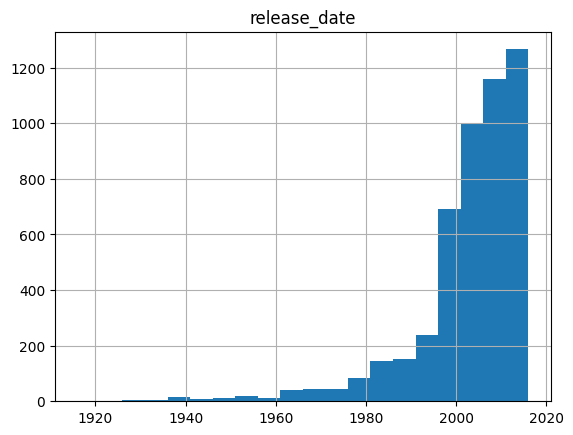

In [138]:
%matplotlib inline

imdb_df.hist(column='release_date', bins=20)

In [142]:
# Summarize the IMDb score distribution

min = imdb_df['imdb_score'].min()
max = imdb_df['imdb_score'].max()
mean = imdb_df['imdb_score'].mean()
std = imdb_df['imdb_score'].std()

print("The min score is {}, the max score is {}, the mean of the scores is {}, and the standard deviation is {}".format(min, max, mean, std))

The min score is 1.6, the max score is 9.3, the mean of the scores is 6.417227401702473, and the standard deviation is 1.1144241317923083


Missing duration values are replaced with the mean movie duration. Mean imputation is a simple baseline that preserves rows while avoiding an implausible zero-duration value.

In [ ]:
imdb_df.hist(column='release_date', bins=20)

In [143]:
imdb_df.duration = imdb_df.duration.fillna(imdb_df.duration.mean())

In [151]:
missingCount = imdb_df.isnull().sum()
missingCount

color                        0
director_name                0
num_critic_for_reviews       0
duration                     0
director_facebook_likes      0
actor_3_facebook_likes       0
actor_2_name                 0
actor_1_facebook_likes       0
gross                        0
genres                       0
actor_1_name                 0
movie_title                  0
num_voted_users              0
cast_total_facebook_likes    0
actor_3_name                 0
facenumber_in_poster         0
plot_keywords                0
movie_imdb_link              0
num_user_for_reviews         0
language                     0
country                      0
content_rating               0
budget                       0
release_date                 0
actor_2_facebook_likes       0
imdb_score                   0
aspect_ratio                 0
movie_facebook_likes         0
dtype: int64

In [152]:
# Mean-impute remaining numeric columns
# Recalculate missing-value counts
for x, f in missingCount.iteritems():
  if f != 0:
    imdb_df[x] = imdb_df[x].fillna(imdb_df[x].mean())

missingCount = imdb_df.isnull().sum()
missingCount

<ipython-input-152-5c02a328c657>:3: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for x, f in missingCount.iteritems():


color                        0
director_name                0
num_critic_for_reviews       0
duration                     0
director_facebook_likes      0
actor_3_facebook_likes       0
actor_2_name                 0
actor_1_facebook_likes       0
gross                        0
genres                       0
actor_1_name                 0
movie_title                  0
num_voted_users              0
cast_total_facebook_likes    0
actor_3_name                 0
facenumber_in_poster         0
plot_keywords                0
movie_imdb_link              0
num_user_for_reviews         0
language                     0
country                      0
content_rating               0
budget                       0
release_date                 0
actor_2_facebook_likes       0
imdb_score                   0
aspect_ratio                 0
movie_facebook_likes         0
dtype: int64